# SIOC 251 – Homework 0
## Prism Dispersion and the Dark Side of the Moon

**Author:** Sophie Wynn  
**Course:** SIOC 251 – Radiative Transfer  
**Date:** Spring 2026

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import os

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

## 1. Refractive Index Model

The refractive index of the prism material varies with wavelength:

$$n(\lambda) = 1.50 + \frac{0.004}{\lambda^2}$$

where $\lambda$ is in microns.

In [2]:
def refractive_index(lam):
    """Compute refractive index for wavelength lam (in microns)."""
    return 1.50 + 0.004 / lam**2

# Wavelengths and colors to simulate
wavelengths = {
    'Violet': (0.40, '#8B00FF'),
    'Blue':   (0.45, '#0000FF'),
    'Cyan':   (0.50, '#00BFFF'),
    'Green':  (0.55, '#00CC00'),
    'Yellow': (0.58, '#FFD700'),
    'Orange': (0.62, '#FF8C00'),
    'Red':    (0.70, '#FF0000'),
}

print(f"{'Color':<10} {'λ (µm)':<10} {'n(λ)':<10}")
print("-" * 30)
for color, (lam, _) in wavelengths.items():
    print(f"{color:<10} {lam:<10.2f} {refractive_index(lam):<10.5f}")

Color      λ (µm)     n(λ)      
------------------------------
Violet     0.40       1.52500   
Blue       0.45       1.51975   
Cyan       0.50       1.51600   
Green      0.55       1.51322   
Yellow     0.58       1.51189   
Orange     0.62       1.51041   
Red        0.70       1.50816   


## 2. Ray-Tracing Model

We trace rays through an equilateral triangle prism using Snell's law:

$$n_1 \sin(\theta_1) = n_2 \sin(\theta_2)$$

The prism is an equilateral triangle (apex angle = 60°). Light enters horizontally from the left.

In [3]:
def snell(theta_i, n1, n2):
    """Apply Snell's law. Returns refracted angle (radians), or None for TIR."""
    sin_t = n1 * np.sin(theta_i) / n2
    if abs(sin_t) > 1.0:
        return None  # Total internal reflection
    return np.arcsin(sin_t)


def trace_ray_through_prism(lam, apex_angle_deg=60.0, incident_angle_deg=45.0):
    """
    Trace a ray of wavelength lam (microns) through an equilateral prism.
    
    Parameters
    ----------
    lam : float
        Wavelength in microns.
    apex_angle_deg : float
        Apex angle of prism in degrees (default 60 for equilateral).
    incident_angle_deg : float
        Angle of incidence on the first prism face (degrees from normal).
    
    Returns
    -------
    deviation : float
        Total deviation angle of the ray in degrees.
    theta_exit : float
        Exit angle from prism normal at second face (degrees).
    """
    n = refractive_index(lam)
    n_air = 1.0
    A = np.radians(apex_angle_deg)
    theta1 = np.radians(incident_angle_deg)
    
    # Refraction at first surface (air -> glass)
    theta2 = snell(theta1, n_air, n)
    if theta2 is None:
        return None, None
    
    # Angle of incidence at second surface
    theta3 = A - theta2
    
    # Refraction at second surface (glass -> air)
    theta4 = snell(theta3, n, n_air)
    if theta4 is None:
        return None, None
    
    # Total deviation
    deviation = (theta1 - theta2) + (theta4 - theta3)
    
    return np.degrees(deviation), np.degrees(theta4)


print(f"{'Color':<10} {'λ (µm)':<10} {'n(λ)':<10} {'Deviation (°)':<15} {'Exit angle (°)':<15}")
print("-" * 60)
for color, (lam, _) in wavelengths.items():
    dev, exit_ang = trace_ray_through_prism(lam)
    print(f"{color:<10} {lam:<10.2f} {refractive_index(lam):<10.5f} {dev:<15.4f} {exit_ang:<15.4f}")

Color      λ (µm)     n(λ)       Deviation (°)   Exit angle (°) 
------------------------------------------------------------
Violet     0.40       1.52500    39.7442         54.7442        
Blue       0.45       1.51975    39.2380         54.2380        
Cyan       0.50       1.51600    38.8795         53.8795        
Green      0.55       1.51322    38.6160         53.6160        
Yellow     0.58       1.51189    38.4901         53.4901        
Orange     0.62       1.51041    38.3502         53.3502        
Red        0.70       1.50816    38.1397         53.1397        


## 3. Ray Path Visualization

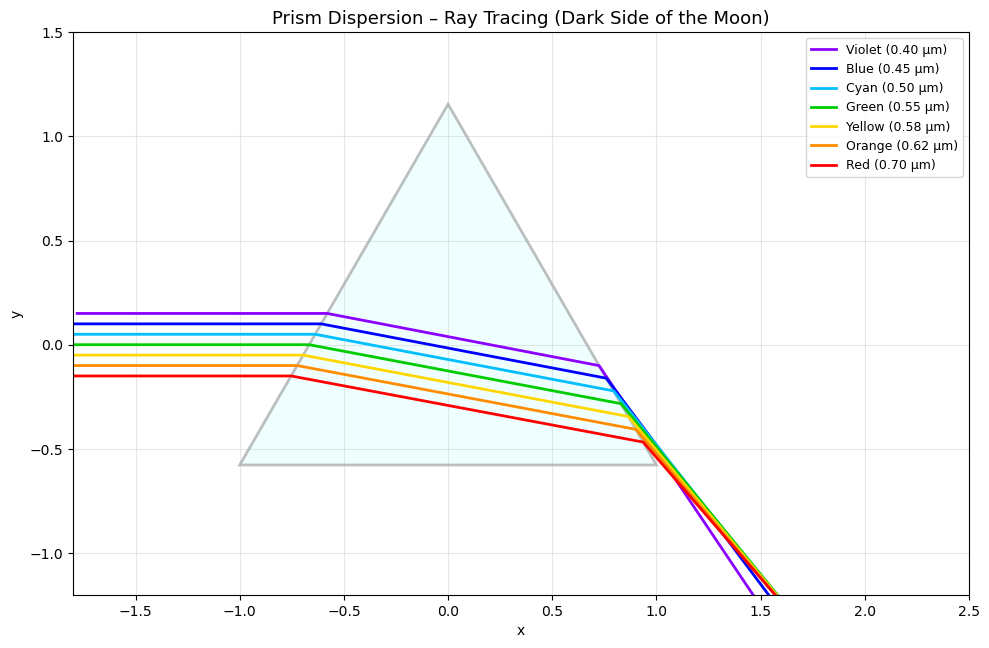

Figure saved to figures/prism_dispersion.png


In [4]:
def get_prism_geometry(apex_angle_deg=60.0, base=2.0):
    """
    Return vertices of an equilateral prism (2D triangle).
    Prism is centered near the origin.
    """
    h = base * np.sqrt(3) / 2
    vertices = np.array([
        [0.0,  2*h/3],   # apex
        [-base/2, -h/3], # bottom-left
        [ base/2, -h/3], # bottom-right
    ])
    return vertices


def compute_ray_path(lam, entry_y=0.0, incident_angle_deg=45.0, prism_base=2.0):
    """
    Compute the geometric path of a ray through the prism.
    Returns list of (x, y) points: [entry_start, entry_point, exit_point, exit_end].
    """
    n = refractive_index(lam)
    n_air = 1.0
    A = np.radians(60.0)
    theta1 = np.radians(incident_angle_deg)

    # Left face of prism: normal points left (-x direction)
    # Ray comes in horizontally from the left
    theta2 = snell(theta1, n_air, n)
    if theta2 is None:
        return None

    # Entry point on left face of prism
    # Left face goes from apex (0, 2h/3) to bottom-left (-base/2, -h/3)
    h = prism_base * np.sqrt(3) / 2
    entry_x = -prism_base/2 + (entry_y - (-h/3)) / (np.tan(np.radians(60)))
    entry_pt = np.array([entry_x, entry_y])

    # Direction inside prism after first refraction
    # Left face normal is at 30° from vertical -> pointing left
    face1_normal_angle = np.radians(30)  # angle of left face normal from horizontal
    # Refracted ray direction inside prism
    ray_angle_inside = incident_angle_deg - np.degrees(theta1) + np.degrees(theta2)
    # Simplified: ray goes right and slightly down after first refraction
    # Use angular geometry: inside ray makes angle theta2 with left face normal
    # Left face normal direction: (cos(210°), sin(210°)) i.e. pointing right-and-down
    # We'll use a direct geometric approach:
    # Incoming ray direction: (1, 0) (horizontal, going right)
    d_in = np.array([1.0, 0.0])
    # Left face outward normal (pointing left, into the incoming ray)
    left_face_normal = np.array([-np.cos(np.radians(30)), -np.sin(np.radians(30))])  # pointing upper-left
    # Actually let's define more carefully:
    # Left face runs from (-1, -h/3) to (0, 2h/3) for base=2
    # Face direction vector: (1, sqrt(3)) normalized
    face1_dir = np.array([1, np.sqrt(3)]) / 2  # unit vector along left face
    face1_normal_outward = np.array([-np.sqrt(3), 1]) / 2  # outward (pointing left)

    # cos of incidence angle
    cos_i = -np.dot(d_in, face1_normal_outward)  # should be positive
    # Refracted direction inside prism via vector Snell's law:
    sin_t = (n_air / n) * np.sqrt(1 - cos_i**2)
    cos_t = np.sqrt(1 - sin_t**2)
    d_refracted = (n_air/n) * d_in + (n_air/n * cos_i - cos_t) * face1_normal_outward
    d_refracted = d_refracted / np.linalg.norm(d_refracted)

    # Find intersection of refracted ray with right face of prism
    # Right face: from (base/2, -h/3) to (0, 2h/3)
    # Parametric: P = entry_pt + t * d_refracted
    # Right face: x = base/2 - s*(base/2), y = -h/3 + s*(h) for s in [0,1]
    # Solve:
    p1 = np.array([prism_base/2, -h/3])  # bottom of right face
    p2 = np.array([0.0, 2*h/3])          # apex
    face2_dir = p2 - p1

    # Solve entry_pt + t*d_refracted = p1 + s*face2_dir
    # [d_refracted, -face2_dir] * [t, s]^T = p1 - entry_pt
    A_mat = np.column_stack([d_refracted, -face2_dir])
    b_vec = p1 - entry_pt
    try:
        params = np.linalg.solve(A_mat, b_vec)
    except np.linalg.LinAlgError:
        return None
    t, s = params
    exit_pt = entry_pt + t * d_refracted

    # Outward normal of right face (pointing right)
    face2_normal_outward = np.array([np.sqrt(3), 1]) / 2  # outward right

    # Angle of incidence on right face
    cos_i2 = -np.dot(d_refracted, -face2_normal_outward)  # ray hits from inside
    cos_i2 = np.dot(d_refracted, face2_normal_outward)

    # Refraction at exit face (glass -> air) using vector form
    face2_normal_inward = -face2_normal_outward
    cos_i2 = -np.dot(d_refracted, face2_normal_inward)
    sin_i2 = np.sqrt(max(0, 1 - cos_i2**2))
    sin_t2 = (n / n_air) * sin_i2
    if sin_t2 > 1.0:
        return None  # TIR
    cos_t2 = np.sqrt(1 - sin_t2**2)
    d_exit = (n/n_air) * d_refracted + (n/n_air * cos_i2 - cos_t2) * face2_normal_inward
    d_exit = d_exit / np.linalg.norm(d_exit)

    # Extend exit ray outward
    exit_end = exit_pt + 1.5 * d_exit

    # Entry ray from the left
    entry_start = entry_pt - np.array([1.2, 0.0])

    return [entry_start, entry_pt, exit_pt, exit_end]


# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

prism_base = 2.0
h = prism_base * np.sqrt(3) / 2
vertices = get_prism_geometry(base=prism_base)
prism_patch = Polygon(vertices, closed=True, facecolor='lightcyan', edgecolor='gray', alpha=0.5, linewidth=2)
ax.add_patch(prism_patch)

# Trace rays at slightly different y-positions so they're visible
y_positions = np.linspace(0.15, -0.15, len(wavelengths))

for (color, (lam, hex_color)), entry_y in zip(wavelengths.items(), y_positions):
    path = compute_ray_path(lam, entry_y=entry_y)
    if path is not None:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, color=hex_color, linewidth=2, label=f"{color} ({lam:.2f} µm)")

ax.set_xlim(-1.8, 2.5)
ax.set_ylim(-1.2, 1.5)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Prism Dispersion – Ray Tracing (Dark Side of the Moon)', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('figures/prism_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to figures/prism_dispersion.png")

## 4. Analysis

### Based on the wavelength dependence of n(λ)

*[Write your answer here – discuss how n decreases with increasing wavelength, meaning shorter wavelengths (violet) bend more than longer wavelengths (red), producing the rainbow spread seen in the album cover.]*

### Based on the ray-tracing figure

*[Write your answer here – compare the ray paths in the figure to the album cover. Are the colors in the correct order? Is the spread physically consistent?]*

## Model Verification

*Describe at least one verification experiment here. Example: test that when n=1 (no glass, just air), the ray passes straight through without bending. Or test Snell's law with a known angle.*

In [5]:
# Verification: For n1 == n2, refracted angle should equal incident angle
theta_in = np.radians(30.0)
theta_out = snell(theta_in, n1=1.5, n2=1.5)
print(f"Verification: snell(30°, n1=1.5, n2=1.5) = {np.degrees(theta_out):.4f}° (expected 30.0°)")
assert abs(np.degrees(theta_out) - 30.0) < 1e-8, "Snell's law verification failed!"
print("PASSED")

# Verification: TIR check – angle above critical angle should return None
n_glass = 1.5
critical_angle = np.degrees(np.arcsin(1.0 / n_glass))
result_tir = snell(np.radians(critical_angle + 5), n1=n_glass, n2=1.0)
print(f"\nVerification: TIR above critical angle ({critical_angle:.1f}°) returns: {result_tir} (expected None)")
assert result_tir is None, "TIR check failed!"
print("PASSED")

Verification: snell(30°, n1=1.5, n2=1.5) = 30.0000° (expected 30.0°)
PASSED

Verification: TIR above critical angle (41.8°) returns: None (expected None)
PASSED


## AI Usage

*[Describe here whether and how you used AI tools (e.g., Claude, ChatGPT) to assist with this assignment. Include what aspects were helped by AI and what you wrote yourself.]*